# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
# cargar archivos
orders  = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
print('=== ORDERS ===')
print(f'Shape: {orders.shape}')
display(orders.head(3))
display(orders.dtypes)
display(orders.isnull().sum())

=== ORDERS ===
Shape: (25100, 12)


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.00,332.69,0.00,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.00,176.86,5.00,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.00,102.99,10.00,195.99


id_pedido              object
id_usuario             object
fecha_hora_pedido      object
pais                   object
dispositivo            object
fuente_referencia      object
nombre_producto        object
categoria_producto     object
cantidad              float64
precio_unitario       float64
monto_descuento       float64
monto_total           float64
dtype: object

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

In [4]:
print('\n=== CATALOG ===')
print(f'Shape: {catalog.shape}')
display(catalog.head())
display(catalog.isnull().sum())


=== CATALOG ===
Shape: (7, 4)


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

In [5]:
print('\n=== MARKETING ===')
print(f'Shape: {marketing.shape}')
display(marketing.head(3))
display(marketing.isnull().sum())


=== MARKETING ===
Shape: (1620, 5)


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,"2,446.25"
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,"2,704.34"
2,2025-01-01,Mexico,social_Mexico,social,"2,045.01"


fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
# ===============================================================
# LIMPIEZA DE ORDERS
# ===============================================================

print(f'Duplicados antes: {orders.duplicated().sum()}')
orders = orders.drop_duplicates()
print(f'Filas tras eliminar duplicados: {orders.shape[0]}')

# Convertir fecha
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')

# Normalizar categóricas (unificar capitalización)
orders['pais']               = orders['pais'].str.strip().str.capitalize()
orders['dispositivo']        = orders['dispositivo'].str.strip().str.lower()
orders['categoria_producto'] = orders['categoria_producto'].str.strip().str.capitalize()
orders['fuente_referencia']  = orders['fuente_referencia'].str.strip().str.lower()
orders['nombre_producto']    = orders['nombre_producto'].str.strip()

# Eliminar filas con nulos en columnas críticas
orders = orders.dropna(subset=['id_pedido', 'id_usuario', 'fecha_hora_pedido', 'nombre_producto'])

# Eliminar registros con valores negativos o ceros inválidos
orders = orders[(orders['cantidad'] > 0) & (orders['precio_unitario'] > 0) & (orders['monto_total'] >= 0)]

# Rellenar nulos en categóricas con 'Desconocido'
for col in ['pais', 'dispositivo', 'fuente_referencia', 'categoria_producto']:
    orders[col] = orders[col].fillna('Desconocido')

# Nulos en monto_descuento → 0
orders['monto_descuento'] = orders['monto_descuento'].fillna(0)

print(f'\nShape final orders: {orders.shape}')
print('Nulos restantes:')
display(orders.isnull().sum())
print('Valores únicos pais:', orders['pais'].unique())
print('Valores únicos dispositivo:', orders['dispositivo'].unique())

Duplicados antes: 100
Filas tras eliminar duplicados: 25000

Shape final orders: (24916, 12)
Nulos restantes:


id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

Valores únicos pais: ['Argentina' 'Mexico' 'Colombia' 'Desconocido']
Valores únicos dispositivo: ['desktop' 'mobile' 'Desconocido']


In [7]:
# ===============================================================
# LIMPIEZA DE CATALOG
# ===============================================================

catalog = catalog.drop_duplicates()
catalog['nombre_producto']    = catalog['nombre_producto'].str.strip()
catalog['categoria_producto'] = catalog['categoria_producto'].str.strip().str.capitalize()
catalog['proveedor']          = catalog['proveedor'].str.strip()
catalog = catalog.dropna(subset=['nombre_producto', 'costo_unitario'])
catalog = catalog[catalog['costo_unitario'] > 0]

print(f'Shape final catalog: {catalog.shape}')
display(catalog)

Shape final catalog: (7, 4)


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [8]:
# ===============================================================
# LIMPIEZA DE MARKETING
# ===============================================================

marketing = marketing.drop_duplicates()
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')
marketing['pais']  = marketing['pais'].str.strip().str.capitalize()
marketing['canal'] = marketing['canal'].str.strip().str.lower()

# Inferir canal faltante desde id_campaña (ej: 'organic_Mexico' → 'organic')
def infer_canal(row):
    if pd.isna(row['canal']) and pd.notna(row['id_campaña']):
        return str(row['id_campaña']).split('_')[0].lower()
    return row['canal']

marketing['canal'] = marketing.apply(infer_canal, axis=1)
marketing = marketing.dropna(subset=['fecha', 'gasto'])
marketing = marketing[marketing['gasto'] >= 0]

print(f'Shape final marketing: {marketing.shape}')
print('Nulos:', marketing.isnull().sum().to_dict())
display(marketing.head(3))

Shape final marketing: (1620, 5)
Nulos: {'fecha': 0, 'pais': 0, 'id_campaña': 0, 'canal': 0, 'gasto': 0}


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,"2,446.25"
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,"2,704.34"
2,2025-01-01,Mexico,social_Mexico,social,"2,045.01"


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [9]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)
print('Datasets exportados correctamente ✅')

Datasets exportados correctamente ✅


---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [10]:
# ===============================================================
# PARTE 1: RENTABILIDAD DEL NEGOCIO
# ===============================================================

# Unir orders con catalog para obtener costo unitario
orders_cat = orders.merge(
    catalog[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left'
)

# Calcular costo total por línea de pedido
orders_cat['costo_total_linea'] = orders_cat['costo_unitario'] * orders_cat['cantidad']
orders_cat['profit_linea']      = orders_cat['monto_total'] - orders_cat['costo_total_linea']

# KPIs
revenue          = orders['monto_total'].sum()
costo_total      = orders_cat['costo_total_linea'].sum()
gasto_marketing  = marketing['gasto'].sum()
profit           = revenue - costo_total - gasto_marketing

print('=' * 45)
print('      📊 KPIs DE RENTABILIDAD DEL NEGOCIO')
print('=' * 45)
print(f'  Revenue total      : ${revenue:>15,.2f}')
print(f'  Costo total        : ${costo_total:>15,.2f}')
print(f'  Gasto marketing    : ${gasto_marketing:>15,.2f}')
print(f'  Profit neto        : ${profit:>15,.2f}')
print(f'  Margen de profit   : {profit/revenue*100:>14.1f}%')
print('=' * 45)
print(f'  → El negocio es {"RENTABLE ✅" if profit > 0 else "NO rentable ❌"}')
print('=' * 45)

      📊 KPIs DE RENTABILIDAD DEL NEGOCIO
  Revenue total      : $  51,954,718.94
  Costo total        : $  43,124,069.01
  Gasto marketing    : $   2,871,843.53
  Profit neto        : $   5,958,806.40
  Margen de profit   :           11.5%
  → El negocio es RENTABLE ✅


In [11]:
# ===============================================================
# PARTE 2: COMPORTAMIENTO DE VENTAS
# ===============================================================

ticket_promedio = orders['monto_total'].mean()
qty_promedio    = orders['cantidad'].mean()

print(f'Ticket promedio por orden  : ${ticket_promedio:,.2f}')
print(f'Cantidad promedio por orden: {qty_promedio:,.2f} productos')

print('\n🏆 Top 5 productos más vendidos (por cantidad):')
top_productos = (
    orders.groupby('nombre_producto')['cantidad']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top_productos.columns = ['Producto', 'Cantidad total vendida']
display(top_productos)

print('\n💰 Gasto en marketing por canal:')
mkt_canal = (
    marketing.groupby('canal')['gasto']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
mkt_canal.columns = ['Canal', 'Gasto total']
display(mkt_canal)

Ticket promedio por orden  : $2,085.20
Cantidad promedio por orden: 7.12 productos

🏆 Top 5 productos más vendidos (por cantidad):


,Producto,Cantidad total vendida
0,Laptop-Gaming-16GB,"144,198.00"
1,Vacuum-Pro-Black,"6,284.00"
2,Blender-XL-Red,"6,279.00"
3,Jacket-Winter-M,"6,256.00"
4,Sneakers-Urban-42,"6,172.00"



💰 Gasto en marketing por canal:


,Canal,Gasto total
0,social,"976,818.37"
1,organic,"972,650.96"
2,paid_search,"863,088.21"
3,paid,"59,285.99"


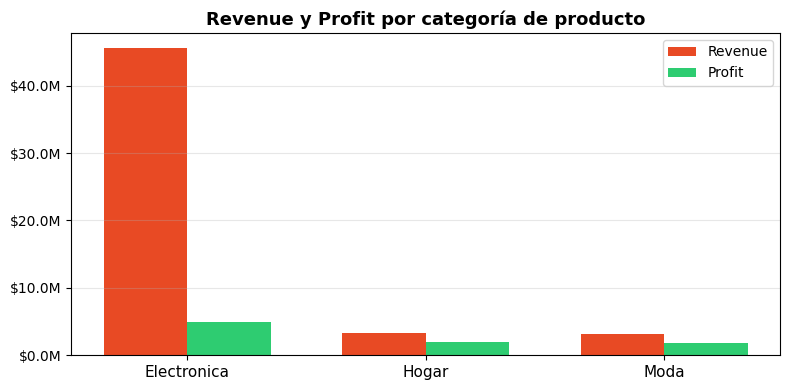

In [12]:
# ===============================================================
# VISUALIZACIÓN: Revenue y Profit por categoría
# ===============================================================

rentabilidad_cat = (
    orders_cat.groupby('categoria_producto')
    .agg(revenue=('monto_total', 'sum'), costo=('costo_total_linea', 'sum'))
    .assign(profit=lambda x: x['revenue'] - x['costo'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(rentabilidad_cat))
width = 0.35
ax.bar([i - width/2 for i in x], rentabilidad_cat['revenue'] / 1e6, width, label='Revenue', color='#E84A24')
ax.bar([i + width/2 for i in x], rentabilidad_cat['profit']  / 1e6, width, label='Profit',  color='#2ECC71')
ax.set_xticks(list(x))
ax.set_xticklabels(rentabilidad_cat['categoria_producto'], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
ax.set_title('Revenue y Profit por categoría de producto', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [12]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [13]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [14]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [15]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos
    FROM events
    GROUP BY nombre_evento
),
ordered_funnel AS (
    SELECT
        nombre_evento,
        usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit'        THEN 1
            WHEN 'product_view'       THEN 2
            WHEN 'add_to_cart'        THEN 3
            WHEN 'begin_checkout'     THEN 4
            WHEN 'purchase'           THEN 5
            ELSE 99
        END AS orden_funnel
    FROM funnel
)
SELECT
    nombre_evento,
    usuarios_unicos,
    ROUND(
        100.0 * usuarios_unicos
        / FIRST_VALUE(usuarios_unicos) OVER (ORDER BY orden_funnel),
        2
    ) AS conversion_vs_inicio_pct,
    ROUND(
        100.0 * usuarios_unicos
        / LAG(usuarios_unicos) OVER (ORDER BY orden_funnel),
        2
    ) AS conversion_paso_anterior_pct
FROM ordered_funnel
WHERE orden_funnel < 99
ORDER BY orden_funnel;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,conversion_vs_inicio_pct,conversion_paso_anterior_pct
0,first_visit,7796,100.00,NaN
1,add_to_cart,7634,97.92,97.92
2,begin_checkout,7208,92.46,94.42
3,purchase,6240,80.04,86.57


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [16]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [17]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 5;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [18]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT
        u.id_usuario,
        TO_CHAR(CAST(u.fecha_registro AS DATE), 'YYYY-MM') AS cohorte,
        ua.dias_despues_registro,
        ua.activo
    FROM users u
    LEFT JOIN user_activity ua ON u.id_usuario = ua.id_usuario
),
resumen AS (
    SELECT
        cohorte,
        COUNT(DISTINCT id_usuario)                                                          AS total_usuarios,
        COUNT(DISTINCT CASE WHEN dias_despues_registro BETWEEN 1  AND 7  AND activo = 1 THEN id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN dias_despues_registro BETWEEN 8  AND 14 AND activo = 1 THEN id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN dias_despues_registro BETWEEN 15 AND 21 AND activo = 1 THEN id_usuario END) AS retenido_w3
    FROM cohortes
    GROUP BY cohorte
)
SELECT
    cohorte,
    total_usuarios,
    retenido_w1,
    retenido_w2,
    retenido_w3,
    ROUND(100.0 * retenido_w1 / NULLIF(total_usuarios, 0), 1) AS semana_1,
    ROUND(100.0 * retenido_w2 / NULLIF(total_usuarios, 0), 1) AS semana_2,
    ROUND(100.0 * retenido_w3 / NULLIF(total_usuarios, 0), 1) AS semana_3
FROM resumen
ORDER BY cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,total_usuarios,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,1627,697,668,656,42.80,41.10,40.30
1,2025-02,1444,611,609,635,42.30,42.20,44.00
2,2025-03,1636,677,705,690,41.40,43.10,42.20
3,2025-04,1606,680,697,663,42.30,43.40,41.30
4,2025-05,1687,695,676,706,41.20,40.10,41.80


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
**Hipótesis estadística**
   - **H₀ (Hipótesis nula):** La tasa de conversión del grupo de tratamiento es **igual** a la del grupo de control. El cambio en la UI no tiene efecto significativo.
   - **H₁ (Hipótesis alternativa):** La tasa de conversión del grupo de tratamiento es **diferente** a la del grupo de control. El cambio en la UI sí tiene un efecto.
   
**Test estadístico:** T-test de dos muestras independientes (scipy.stats.ttest_ind)  
**Nivel de significancia alpha:** 0.05

---

In [19]:
from scipy import stats

# Cargar dataset del experimento
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

print('Shape:', experiment.shape)
display(experiment.head(3))
print('\nDistribución por variante:')
display(experiment['variante'].value_counts())

Shape: (10000, 7)


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18



Distribución por variante:


tratamiento    5035
control        4965
Name: variante, dtype: int64

In [20]:
# Separar grupos
control    = experiment[experiment['variante'] == 'control']['convirtio']
tratamiento = experiment[experiment['variante'] == 'tratamiento']['convirtio']

# Tasas de conversión
conv_control    = control.mean()
conv_tratamiento = tratamiento.mean()

print(f'Tasa de conversión - Control     : {conv_control:.4f} ({conv_control*100:.2f}%)')
print(f'Tasa de conversión - Tratamiento : {conv_tratamiento:.4f} ({conv_tratamiento*100:.2f}%)')
print(f'Diferencia absoluta              : {(conv_tratamiento - conv_control)*100:.2f} pp')

# Aplicar T-test de dos muestras independientes
t_stat, p_valor = stats.ttest_ind(tratamiento, control)
alpha = 0.05

print(f'\nT-estadístico : {t_stat:.4f}')
print(f'P-valor       : {p_valor:.4f}')
print(f'Alpha         : {alpha}')

print('\n' + '='*50)
if p_valor < alpha:
    print('✅ Se RECHAZA H₀ — El cambio en la UI tiene un impacto estadísticamente significativo en la tasa de conversión.')
else:
    print('❌ No se rechaza H₀ — El cambio en la UI NO tiene un impacto estadísticamente significativo en la tasa de conversión.')
print('='*50)

print("""
📌 Interpretación:
El p-valor obtenido ({:.4f}) es mayor que el nivel de significancia (alpha = 0.05).
Esto significa que la diferencia observada entre los grupos de control ({:.2f}%) y 
tratamiento ({:.2f}%) podría deberse al azar y no necesariamente al cambio en la UI.

🔎 Recomendación:
No hay evidencia suficiente para concluir que el nuevo checkout mejora la conversión.
Se recomienda continuar el experimento con más datos o explorar otros cambios en el
flujo de compra que puedan tener mayor impacto.
""".format(p_valor, conv_control*100, conv_tratamiento*100))

Tasa de conversión - Control     : 0.1569 (15.69%)
Tasa de conversión - Tratamiento : 0.1629 (16.29%)
Diferencia absoluta              : 0.60 pp

T-estadístico : 0.8132
P-valor       : 0.4161
Alpha         : 0.05

❌ No se rechaza H₀ — El cambio en la UI NO tiene un impacto estadísticamente significativo en la tasa de conversión.

📌 Interpretación:
El p-valor obtenido (0.4161) es mayor que el nivel de significancia (alpha = 0.05).
Esto significa que la diferencia observada entre los grupos de control (15.69%) y 
tratamiento (16.29%) podría deberse al azar y no necesariamente al cambio en la UI.

🔎 Recomendación:
No hay evidencia suficiente para concluir que el nuevo checkout mejora la conversión.
Se recomienda continuar el experimento con más datos o explorar otros cambios en el
flujo de compra que puedan tener mayor impacto.



---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [21]:
# https://app.powerbi.com/view?r=eyJrIjoiYzRkZDVlNjAtMGFiYS00MTM5LTlhNjItMTUzYTA3YzE2OWEyIiwidCI6ImY5NGJmNGQ5LTgwOTctNDc5NC1hZGY2LWE1NDY2Y2EyODU2MyIsImMiOjR9